# 1869 leavers out of 7043

Count the label on every row.

$$
\dfrac{1869}{7043}
$$

leave, and

$$
\dfrac{5174}{7043}
$$

stay. These fractions are already in lowest terms: $\gcd(1869, 7043) = 1$ and $\gcd(5174, 7043) = 1$.

Predicting Stay for every customer is correct on every stay and wrong on every leave:

$$
\mathrm{accuracy} = \dfrac{5174}{7043},
\qquad
\mathrm{recall} = \dfrac{0}{1869} = 0.
$$

The chart draws both counts from zero. The green bar is the stay count. The clay bar is the leave count.


In [1]:
# Locate the telco table beside this notebook, or under the course root.
import csv
from pathlib import Path

def data_path():
    here = Path.cwd()
    name = "Telco-Customer-Churn.csv"
    for folder in [here, *here.parents]:
        nested = folder / "16-Customer Churn" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists():
            return direct
    raise FileNotFoundError(name)

def read_customers():
    with data_path().open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))
# Base rate, and the accuracy of predicting Stay on every row.
from fractions import Fraction
from math import gcd

rows = read_customers()
left = sum(row["Churn"] == "Yes" for row in rows)
stayed = sum(row["Churn"] == "No" for row in rows)
print(left, stayed, Fraction(left, 7043), Fraction(stayed, 7043))
assert left == 1869 and stayed == 5174
assert gcd(1869, 7043) == 1 and gcd(5174, 7043) == 1
assert Fraction(stayed, 7043) == Fraction(5174, 7043)


1869 5174 1869/7043 5174/7043


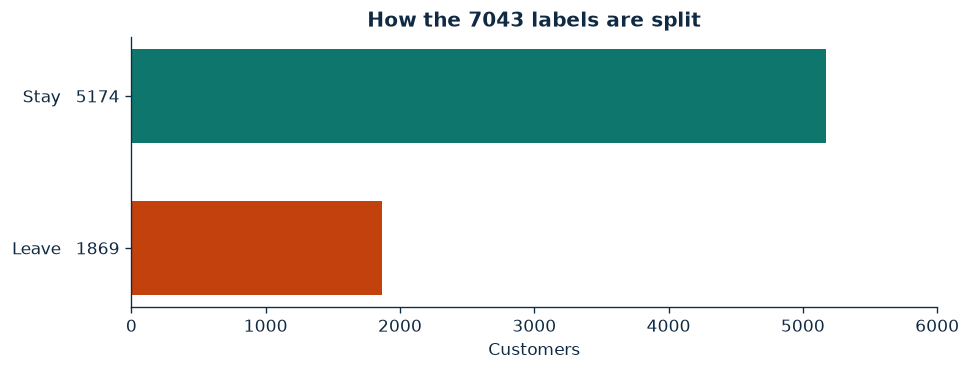

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
    "axes.titlecolor": "#102a43",
})
# Stay in green, leave in clay. The axis starts at zero.
labels = ["Stay   5174", "Leave   1869"]
counts = [5174, 1869]
colors = ["#0f766e", "#c2410c"]
positions = [1, 0]
figure, axis = plt.subplots(figsize=(8.2, 3.2))
axis.barh(positions, counts, color=colors, height=0.62)
axis.set_yticks(positions, labels)
axis.set_xlim(0, 6000)
axis.set_xlabel("Customers")
axis.set_title("How the 7043 labels are split")
figure.tight_layout()


## Pitfall

$5174/7043$ is about 0.735. A model score near that accuracy can be the constant Stay rule wearing a longer name. The recall of that rule is 0.

## Summary

1869 customers leave and 5174 stay. The leave rate is $1869/7043$. Predicting Stay scores $5174/7043$ and finds none of the leavers.
